<a href="https://colab.research.google.com/github/juizykad-netizen/AIML_PYTHON/blob/main/Assignment_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Import Libraries

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re, string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


2. Load the Dataset

In [21]:
# 1. Load data
df = pd.read_csv("tweets.csv")
df.head()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7920 entries, 0 to 7919
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      7920 non-null   int64 
 1   label   7920 non-null   int64 
 2   tweet   7920 non-null   object
dtypes: int64(2), object(1)
memory usage: 185.8+ KB


3. Explore the Dataset

In [22]:
df.info()
df['label'].value_counts()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7920 entries, 0 to 7919
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      7920 non-null   int64 
 1   label   7920 non-null   int64 
 2   tweet   7920 non-null   object
dtypes: int64(2), object(1)
memory usage: 185.8+ KB


,count
label,
0,5894
1,2026


4. Text Cleaning Function

In [23]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", '', text)  # remove links
    text = re.sub(r'@\w+|\#','', text)  # remove mentions & hashtags
    text = text.translate(str.maketrans('', '', string.punctuation))  # remove punctuation
    text = re.sub(r'\d+', '', text)  # remove numbers
    text = text.strip()
    return text

df['clean_text'] = df['tweet'].apply(clean_text)
df[['tweet', 'clean_text']].head()


,tweet,clean_text
0,#fingerprint #Pregnancy Test https://goo.gl/h1...,fingerprint pregnancy test android apps beaut...
1,Finally a transparant silicon case ^^ Thanks t...,finally a transparant silicon case thanks to ...
2,We love this! Would you go? #talk #makememorie...,we love this would you go talk makememories un...
3,I'm wired I know I'm George I was made that wa...,im wired i know im george i was made that way ...
4,What amazing service! Apple won't even talk to...,what amazing service apple wont even talk to m...


5. Train–Test Split

In [24]:
X = df['clean_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


6. TF‑IDF Vectorization

In [25]:
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)


7. Build the Logistic Regression Model

In [26]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)


LogisticRegression(max_iter=1000)

8. Evaluate the Model (Accuracy Required)

Accuracy: 0.884469696969697

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.96      0.92      1179
           1       0.84      0.68      0.75       405

    accuracy                           0.88      1584
   macro avg       0.87      0.82      0.84      1584
weighted avg       0.88      0.88      0.88      1584



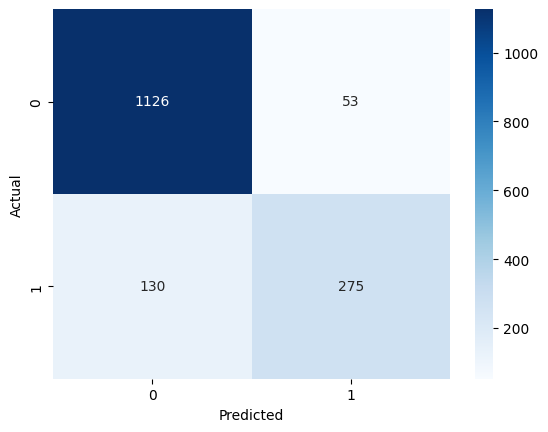

In [27]:
y_pred = model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


9. Predict Sentiment for New Tweets

In [28]:
new_tweets = [
    "I love the new Samsung phone!",
    "This laptop is the worst thing ever."
]

new_clean = [clean_text(t) for t in new_tweets]
new_vec = tfidf.transform(new_clean)
model.predict(new_vec)


array([0, 1])